In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

<h1>Survey Analysis of UC Instructor Viewpoints Survey</h1>

As of November 25, 2025

In [3]:
df = pd.read_csv('survey_results.csv')
df.shape

(195, 52)

In [4]:
df.head()

,Finished,RecordedDate,Q2,Q4_1,Q4_2,Q4_3,Q4_4,Q4_5,Q5_1,Q5_2,...,Q15_4,Q15_13,Q15_12,Q15_5,Q15_6,Q15_7,Q15_8,Q15_9,Q15_10,Q15_11
0,Finished,Recorded Date,Your Consent If you want to participate in thi...,Thinking about students in the University of C...,Thinking about students in the University of C...,Thinking about students in the University of C...,Thinking about students in the University of C...,Thinking about students in the University of C...,"Thinking about teaching in general, please rat...","Thinking about teaching in general, please rat...",...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...
1,TRUE,9/23/25 13:58,Agree,Neutral,Neutral,Strongly agree,Somewhat agree,Strongly disagree,Strongly agree,Strongly agree,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None of the above
2,TRUE,10/3/25 9:32,Agree,Neutral,Neutral,Somewhat agree,Somewhat agree,Somewhat disagree,Strongly agree,Unsure / Unapplicable,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Decline to state,NaN
3,TRUE,11/3/25 12:07,Agree,Neutral,Neutral,Somewhat agree,Somewhat disagree,Strongly agree,Neutral,Strongly agree,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A person who immigrated to the United States,NaN,NaN
4,TRUE,9/23/25 13:58,Agree,Somewhat agree,Neutral,Strongly agree,Strongly agree,Neutral,Somewhat disagree,Strongly agree,...,NaN,NaN,NaN,NaN,A person who is neurodivergent,A person who is first in my family to go to co...,A person from a low-income family background,NaN,NaN,NaN


<h2>Likert Scale Bar Charts (Q4, Q5, Q6)</h2>

<h4>Q4: Thinking about students in the University of California (UC) system, please rate the extent to which you agree with each of the following statements...</h3>

<h4>Q5: Thinking about teaching in general, please rate the extent to which you agree with each of the following statements...</h4>

<h4>Q6: We would like to hear more about your engagement with different teaching practices.  Please rate how confident you feel in engaging in each of the following areas of teaching...</h4>

In [5]:
# change likert scale colors to berkeley branding colors
# see if there are correlations between question items
# reverse "equitable teaching" question to make it consistent

# heatmap or profiles of diff ppl -- are the same people responding to questions in the same way? (i.e. strongly disagreeing with certain statements that show the same mindset)
# clustering or dengigrams

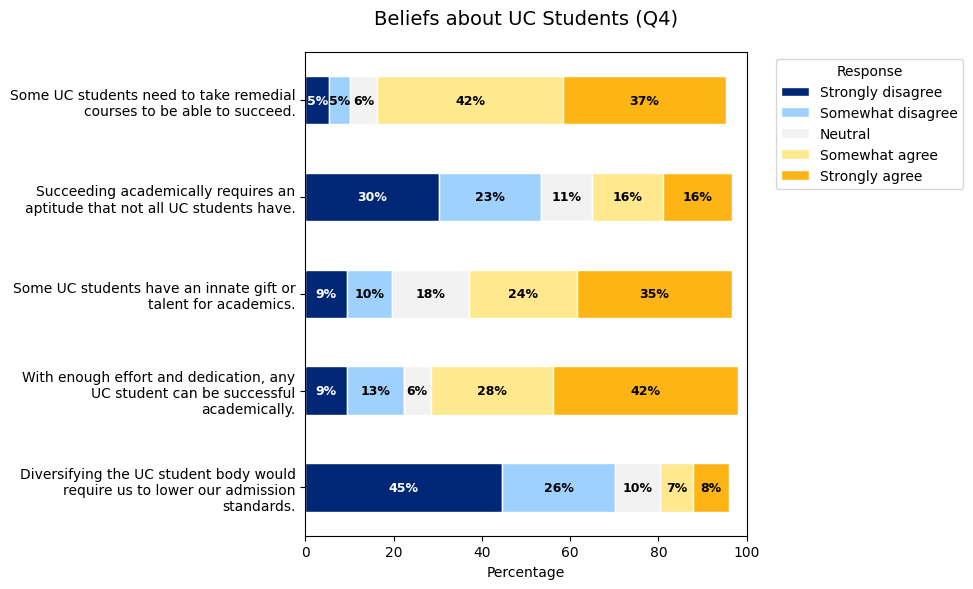

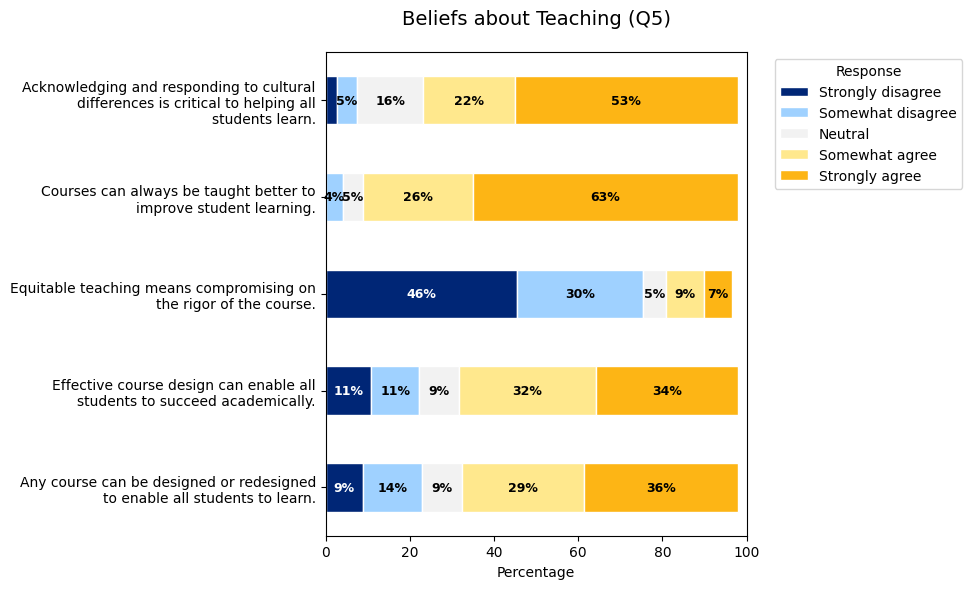

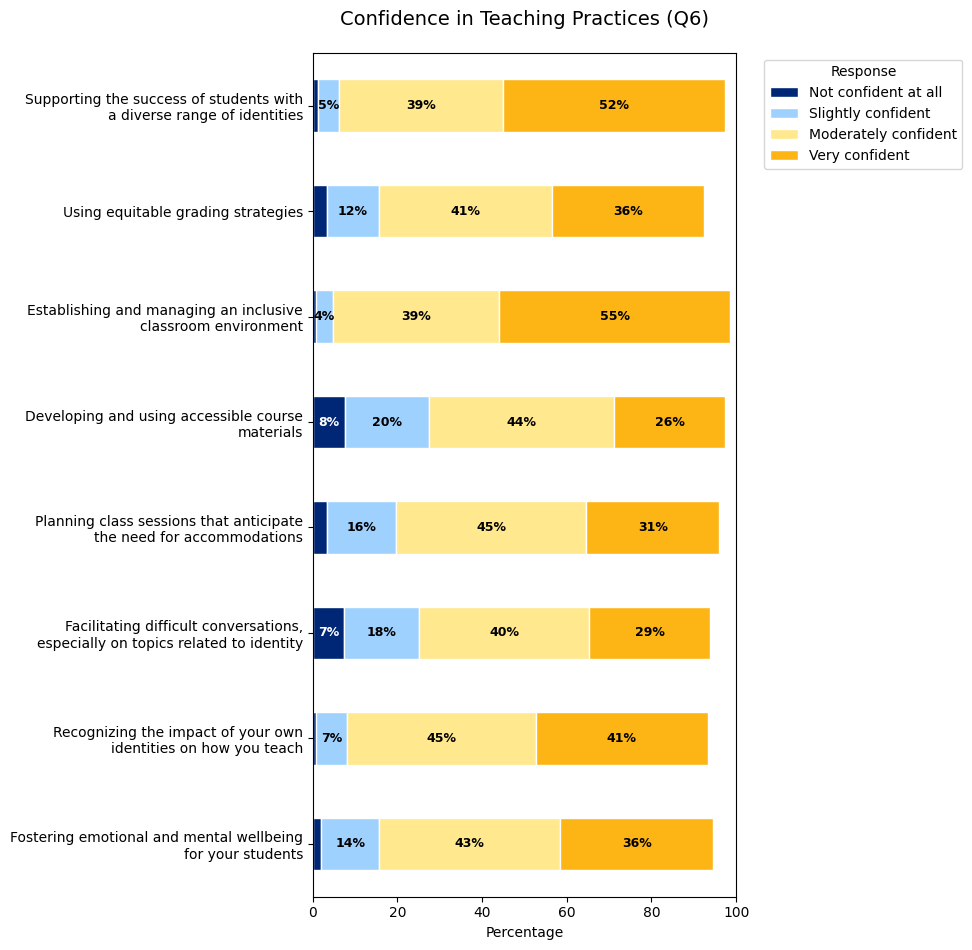

In [6]:
df_questions = pd.read_csv('survey_results.csv', nrows=1)
question_map = df_questions.iloc[0].to_dict()

agree_order = [
    'Strongly disagree', 
    'Somewhat disagree', 
    'Neutral', 
    'Somewhat agree', 
    'Strongly agree'
]

conf_order = [
    'Not confident at all', 
    'Slightly confident', 
    'Moderately confident', 
    'Very confident'
]

# Dark Blue -> Light Blue -> Grey -> Light Yellow -> Gold
custom_colors_5 = ['#002676', '#9FD1FF', '#F2F2F2', '#FFE88D', '#FDB515']
# Text colors for readability: White for dark bars, Black for light bars
text_colors_5 = ['white', 'black', 'black', 'black', 'black']

# We skip the middle Grey (#F2F2F2) to maintain a continuous gradient
custom_colors_4 = ['#002676', '#9FD1FF', '#FFE88D', '#FDB515']
text_colors_4 = ['white', 'black', 'black', 'black']

q4_cols = [c for c in df.columns if c.startswith('Q4_')]
q5_cols = [c for c in df.columns if c.startswith('Q5_')]
q6_cols = [c for c in df.columns if c.startswith('Q6_')]

def plot_likert_block(data, cols, order, title, q_map, color_palette, text_colors):
    results = {}
    
    for col in cols:
        full_text = q_map.get(col, col)
        label = full_text.split('-')[-1].strip() if '-' in full_text else full_text
        label = textwrap.fill(label, width=40)
        
        vc = data[col].value_counts(normalize=True).reindex(order, fill_value=0) * 100
        results[label] = vc

    plot_df = pd.DataFrame(results).T
    
    fig, ax = plt.subplots(figsize=(10, len(cols) * 1.2))
    
    plot_df.plot(kind='barh', stacked=True, ax=ax, color=color_palette, edgecolor='white')
    
    ax.set_title(title, fontsize=14, pad=20)
    ax.set_xlabel('Percentage')
    ax.set_xlim(0, 100)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Response")
    ax.invert_yaxis()
    
    for i, c in enumerate(ax.containers):
        t_color = text_colors[i] if i < len(text_colors) else 'black'
        
        # Only label segments > 4% width
        labels = [f'{v.get_width():.0f}%' if v.get_width() > 4 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', color=t_color, fontsize=9, weight='bold')
    
    plt.tight_layout()
    plt.show()

plot_likert_block(df, q4_cols, agree_order, "Beliefs about UC Students (Q4)", question_map, custom_colors_5, text_colors_5)
plot_likert_block(df, q5_cols, agree_order, "Beliefs about Teaching (Q5)", question_map, custom_colors_5, text_colors_5)
plot_likert_block(df, q6_cols, conf_order, "Confidence in Teaching Practices (Q6)", question_map, custom_colors_4, text_colors_4)

<h2>Bar Charts (Q8, Q9)</h2>

<h4>Q8: How do you prefer to engage in professional development opportunities as part of your instructor role? Please select all that apply.</h4>

<h4>Q9: Which resource to develop your ability to effectively teach all UC students would interest you the most? Please select no more than 3 options.</h4>

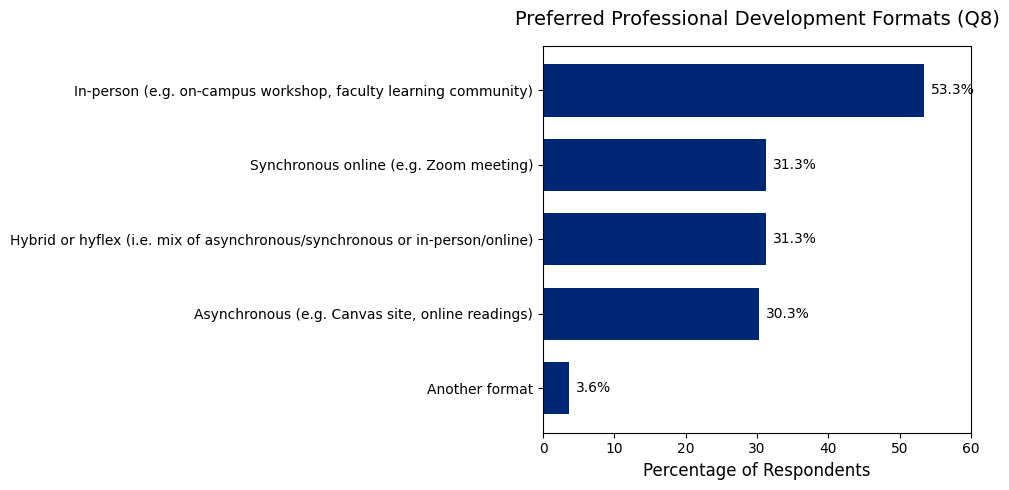

In [7]:
question_row = df_questions.iloc[0]

# Q8 columns are for the question "How do you prefer to engage in professional development...?"
# We exclude the 'TEXT' column which contains open-ended responses for 'Other'
q8_cols = [c for c in df.columns if c.startswith('Q8_') and not c.endswith('_TEXT')]

counts = {}
for col in q8_cols:
    full_label = question_row[col]
    
    # Extract the option label (remove the question stem)
    # The format is "Question - Selected Choice - Option"
    if " - Selected Choice - " in full_label:
        label = full_label.split(" - Selected Choice - ")[-1].strip()
    else:
        label = full_label.split("-")[-1].strip()
        
    # Simplify the label for "Another format"
    if "Another format" in label:
        label = "Another format"
    
    # Count non-null values (since selecting an option populates the cell)
    count = df[col].notna().sum()
    counts[label] = count

# Create df for plot
count_df = pd.DataFrame.from_dict(counts, orient='index', columns=['Count'])
total_respondents = len(df)
count_df['Percentage'] = (count_df['Count'] / total_respondents) * 100

# Sort by popularity
count_df = count_df.sort_values('Percentage', ascending=True)

# Generate the horizontal bar chart
plt.figure(figsize=(10, 5))
ax = count_df['Percentage'].plot(kind='barh', color='#002676', width=0.7)

# Formatting
plt.title('Preferred Professional Development Formats (Q8)', fontsize=14, pad=15)
plt.xlabel('Percentage of Respondents', fontsize=12)
plt.ylabel('')
plt.xlim(0, 60) # Set x-axis limit slightly higher than max value

# Add percentage labels to the ends of the bars
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', padding=5, fontsize=10)

plt.tight_layout()
plt.show()

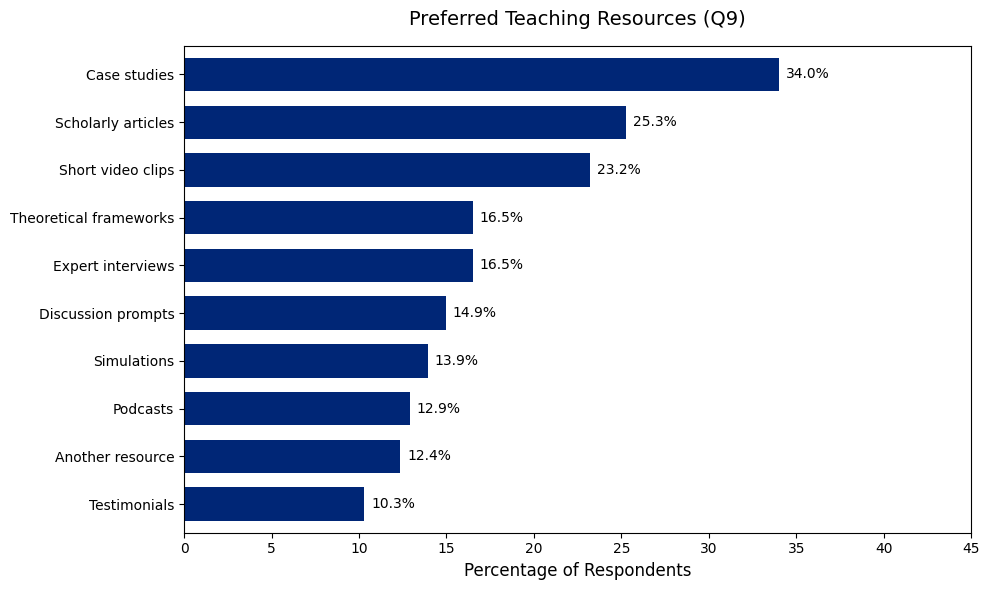

In [16]:
# Identify Q9 columns (excluding the text field)
q9_cols = [c for c in df.columns if c.startswith('Q9_') and not c.endswith('_TEXT')]

counts = {}
for col in q9_cols:
    full_label = question_row[col]
    
    # Extract the option label
    if " - Selected Choice - " in full_label:
        label = full_label.split(" - Selected Choice - ")[-1].strip()
    else:
        label = full_label.split("-")[-1].strip()
        
    # Simplify "Another resource" label
    if "Another resource" in label:
        label = "Another resource"
    
    # Count non-nulls
    count = df[col].notna().sum()
    counts[label] = count

# Create df
count_df = pd.DataFrame.from_dict(counts, orient='index', columns=['Count'])
# Calculate percentage based on total number of respondents
count_df['Percentage'] = (count_df['Count'] / len(df)) * 100

count_df = count_df.sort_values('Percentage', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
ax = count_df['Percentage'].plot(kind='barh', color='#002676', width=0.7)

plt.title('Preferred Teaching Resources (Q9)', fontsize=14, pad=15)
plt.xlabel('Percentage of Respondents', fontsize=12)
plt.ylabel('')
# Set x-limit slightly higher than max value (e.g., 40% or 60%)
plt.xlim(0, 45) 

# Add labels
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', padding=5, fontsize=10)

plt.tight_layout()
plt.show()

# add small description w examples of "another resource"

<h2>Pi Charts (Q11, Q12, Q13)</h2>

<h4>Q11: At which UC campus do you currently teach?</h4>

<h4>Q12: Which of the following best describes your current job title/role? If you hold multiple positions or titles, please select the one that is most relevant to being an instructor on a UC campus.</h4>

<h4>Q13: In which discipline/field do you most often teach? Please select the best option. Note that these disciplinary categories are purposefully broad to help individual respondents to maintain their anonymity when responding to this survey.</h4>

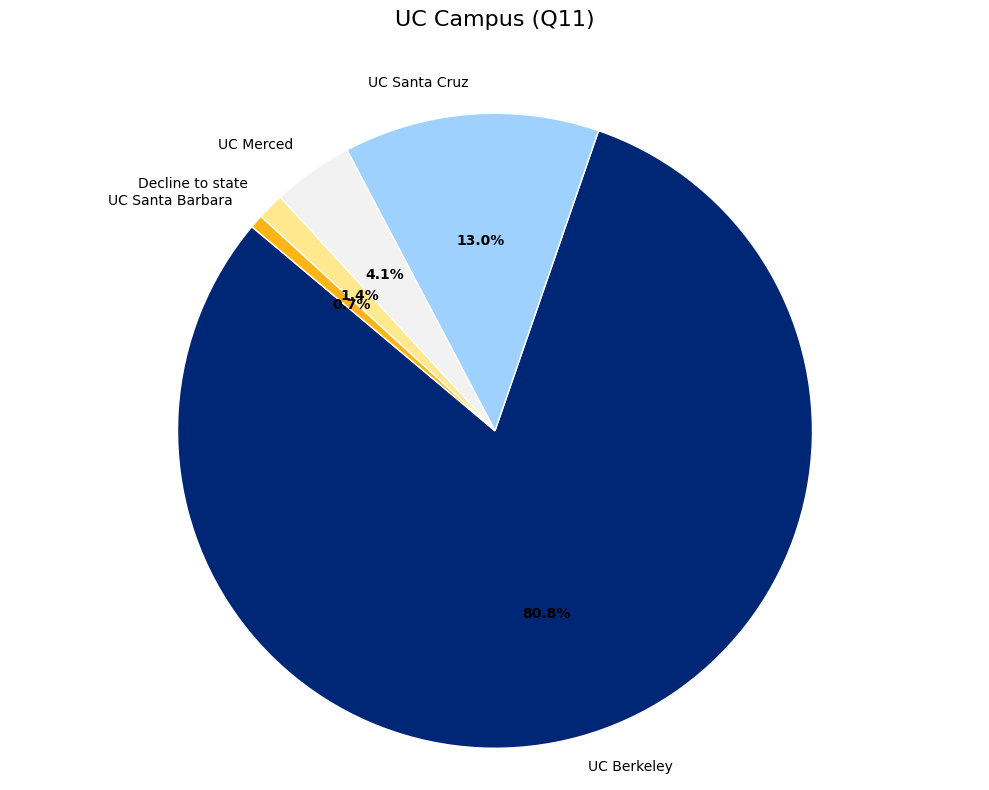

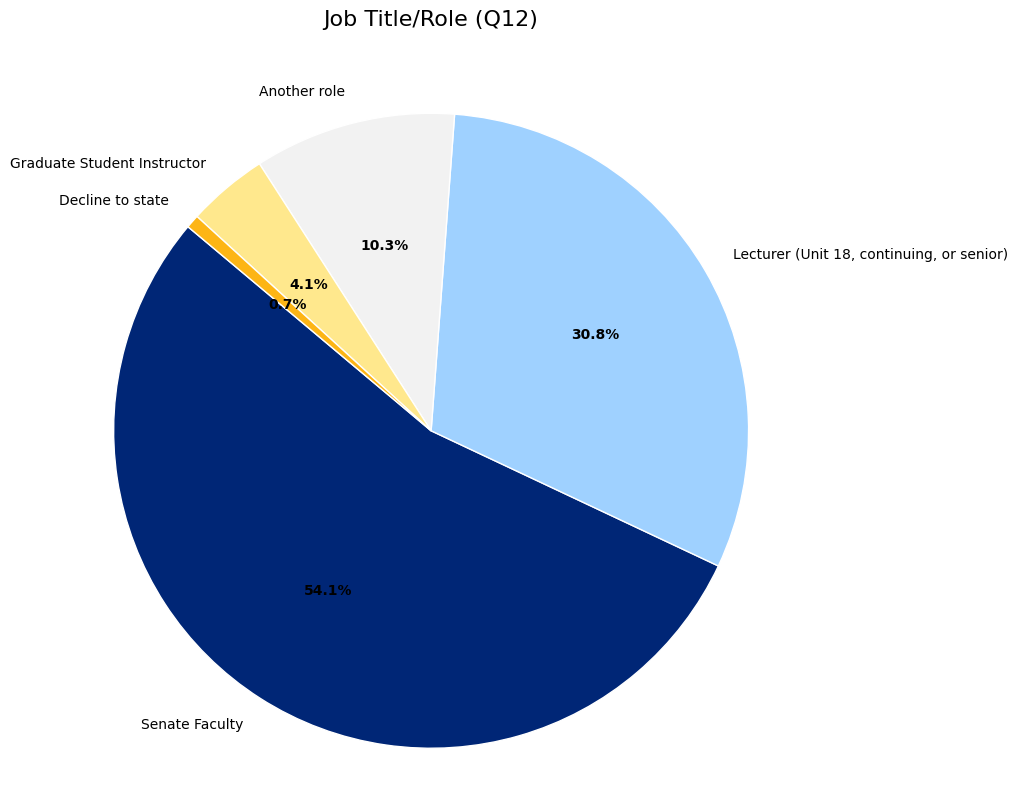

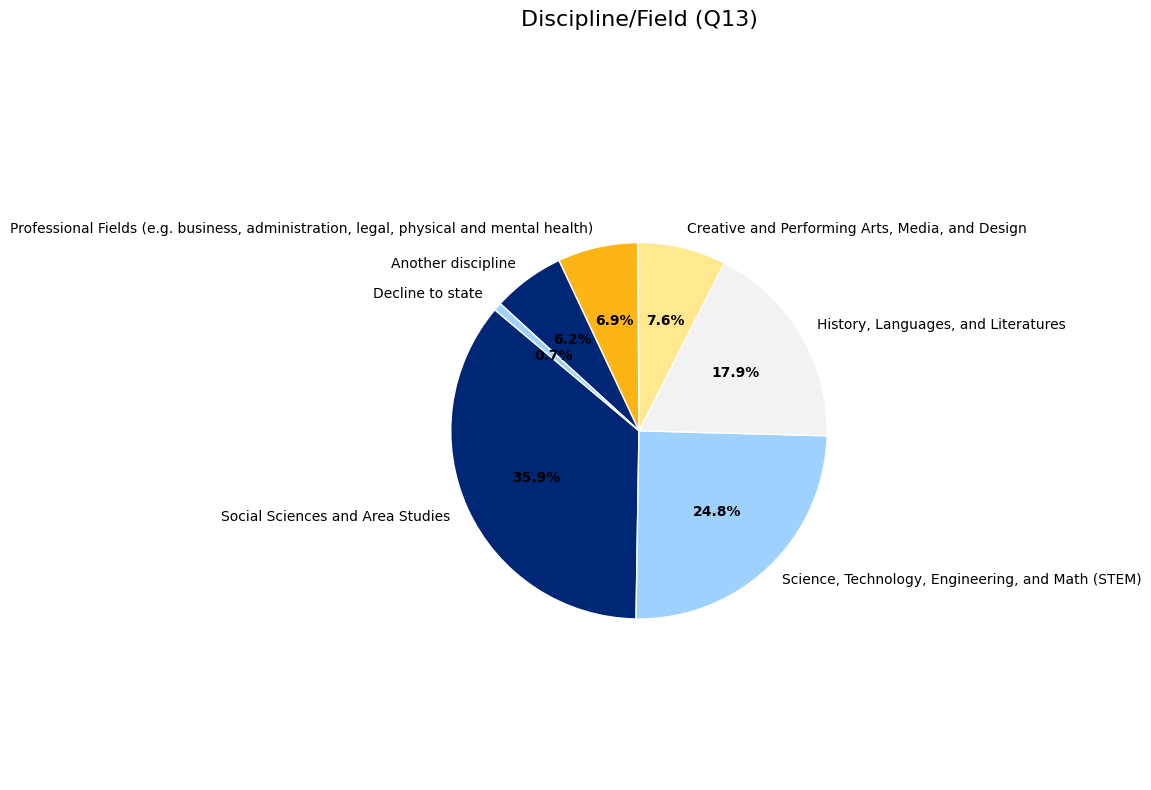

In [15]:
# Q11-13

# This explicitly removes the row where the value is the question text itself.
# This prevents it from appearing as a slice in the pie chart.
df = df[df['Q11'] != 'At which UC campus do you currently teach?']

columns_map = {
    'Q11': 'UC Campus (Q11)',
    'Q12': 'Job Title/Role (Q12)',
    'Q13': 'Discipline/Field (Q13)'
}

custom_colors = ['#002676', '#9FD1FF', '#F2F2F2', '#FFE88D', '#FDB515']

def plot_pie_chart(data, col, title, colors):
    counts = data[col].value_counts()
    
    plt.figure(figsize=(10, 8))
    
    wedges, texts, autotexts = plt.pie(
        counts, 
        labels=counts.index, 
        autopct='%1.1f%%', 
        startangle=140,
        colors=colors,
        wedgeprops={'edgecolor': 'white'}
    )
    
    plt.setp(autotexts, size=10, weight="bold")
    plt.title(title, fontsize=16, pad=40)
    plt.axis('equal')
    
    plt.tight_layout()
    plt.show()

for col, title in columns_map.items():
    plot_pie_chart(df, col, title, custom_colors)

<h2>Summary Table (Q15)</h2>

<h4>Q15: Please select all that apply. I identify as…</h4>

In [ ]:
# Q15
q15_cols = [c for c in df.columns if c.startswith('Q15_')]

counts = {}
total_respondents = len(df)

for col in q15_cols:
    full_text = question_row[col]
    
    # Extract the option label after the dash
    if " - " in full_text:
        label = full_text.split(" - ")[-1].strip()
    else:
        label = full_text
        
    # Count non-null values (selections)
    count = df[col].notna().sum()
    counts[label] = count

# Create summary df
summary_df = pd.DataFrame.from_dict(counts, orient='index', columns=['Count'])
summary_df['Percentage'] = (summary_df['Count'] / total_respondents) * 100

summary_df['Percentage_Str'] = summary_df['Percentage'].map('{:.1f}%'.format)

summary_df = summary_df.sort_values('Count', ascending=False)

summary_df

,Count,Percentage,Percentage_Str
None of the above,43,22.164948,22.2%
A person who is first in my family to go to college,24,12.371134,12.4%
"A Black, Indigenous, and/or person of color (BIPOC)",23,11.855670,11.9%
A person from a low-income family background,22,11.340206,11.3%
A person who immigrated to the United States,22,11.340206,11.3%
A person with a minoritized gender identity in my disicpline,21,10.824742,10.8%
A member of the LGBTQIA+ community,18,9.278351,9.3%
A person who is neurodivergent,18,9.278351,9.3%
A person living with a disability,16,8.247423,8.2%
"A transgender, non-binary, and/or genderqueer person",10,5.154639,5.2%


<h2>Cronbach's Alpha -- Respondent Profiles</h2>

Cronbach's Alpha (Growth/Equity): 0.845
Cronbach's Alpha (Confidence): 0.819


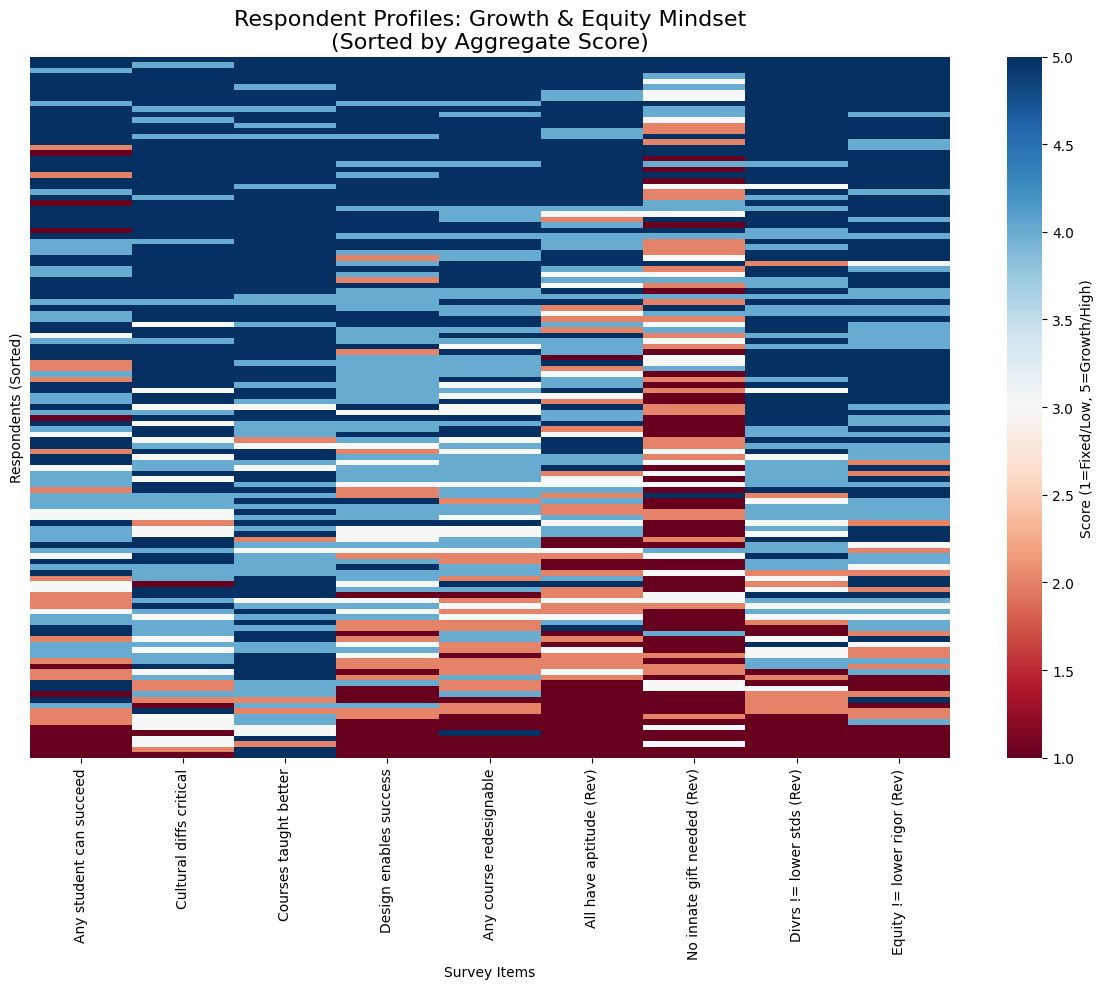

In [17]:
# df = df[df['Q11'] != 'At which UC campus do you currently teach?']

agree_map = {
    'Strongly disagree': 1,
    'Somewhat disagree': 2,
    'Neutral': 3,
    'Somewhat agree': 4,
    'Strongly agree': 5,
    'Unsure / Unapplicable': np.nan
}

conf_map = {
    'Not confident at all': 1,
    'Slightly confident': 2,
    'Moderately confident': 3,
    'Very confident': 4,
    'Unsure / Unapplicable': np.nan
}

df_num = df.copy()
q4_cols = [c for c in df.columns if c.startswith('Q4_')]
q5_cols = [c for c in df.columns if c.startswith('Q5_')]
q6_cols = [c for c in df.columns if c.startswith('Q6_')]

for c in q4_cols + q5_cols:
    df_num[c] = df[c].map(agree_map)
for c in q6_cols:
    df_num[c] = df[c].map(conf_map)

# Reverse Coding for Fixed Mindset Items
# We want High Score = Growth/Equity. So we reverse the "Fixed" items (1->5, 5->1).
# Items: Q4_2 (Aptitude), Q4_3 (Innate Gift), Q4_5 (Lowering Standards), Q5_3 (Compromising Rigor)
reverse_cols = ['Q4_2', 'Q4_3', 'Q4_5', 'Q5_3']
for c in reverse_cols:
    df_num[c + '_rev'] = 6 - df_num[c]

# Define the "Growth/Equity" composite items
growth_cols = ['Q4_4', 'Q5_1', 'Q5_2', 'Q5_4', 'Q5_5', 'Q4_2_rev', 'Q4_3_rev', 'Q4_5_rev', 'Q5_3_rev']

# Calculate Cronbach's Alpha
def cronbach_alpha(df_items):
    df_clean = df_items.dropna()
    item_scores = df_clean.values
    item_vars = item_scores.var(axis=0, ddof=1)
    t_scores = item_scores.sum(axis=1)
    n_items = item_scores.shape[1]
    return n_items / (n_items - 1) * (1 - item_vars.sum() / t_scores.var(ddof=1))

print(f"Cronbach's Alpha (Growth/Equity): {cronbach_alpha(df_num[growth_cols]):.3f}")
print(f"Cronbach's Alpha (Confidence): {cronbach_alpha(df_num[q6_cols]):.3f}")

# Select data and sort by "Total Growth Score" to show profiles
heatmap_data = df_num[growth_cols].dropna()
heatmap_data['Mean_Score'] = heatmap_data.mean(axis=1)
heatmap_data_sorted = heatmap_data.sort_values('Mean_Score', ascending=False).drop('Mean_Score', axis=1)

labels = {
    'Q4_4': 'Any student can succeed',
    'Q5_1': 'Cultural diffs critical',
    'Q5_2': 'Courses taught better',
    'Q5_4': 'Design enables success',
    'Q5_5': 'Any course redesignable',
    'Q4_2_rev': 'All have aptitude (Rev)',
    'Q4_3_rev': 'No innate gift needed (Rev)',
    'Q4_5_rev': 'Divrs != lower stds (Rev)',
    'Q5_3_rev': 'Equity != lower rigor (Rev)'
}
heatmap_data_sorted = heatmap_data_sorted.rename(columns=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data_sorted, cmap='RdBu', vmin=1, vmax=5, 
            cbar_kws={'label': 'Score (1=Fixed/Low, 5=Growth/High)'})
plt.title('Respondent Profiles: Growth & Equity Mindset\n(Sorted by Aggregate Score)', fontsize=16)
plt.yticks([]) # Hide individual respondent IDs
plt.xlabel('Survey Items')
plt.ylabel('Respondents (Sorted)')
plt.tight_layout()
plt.show()